# Introduction to Pytorch

## Import dependencies

If using Google Colab, all the packages listed below should be pre-installed.

In [1]:
# --- Standard libraries ---
import os
import math
import numpy as np
import time
import torch

# --- Imports for plotting ---
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
# For export
set_matplotlib_formats('svg', 'pdf')
from matplotlib.colors import to_rgba

import seaborn as sns
sns.set()

# --- Progress bar ---
from tqdm.notebook import tqdm

## The Basics of Pytorch

The package is called `torch`.

In [6]:
import torch
print("Using torch:", torch.__version__)

Using torch: 2.6.0


PyTorch provides functions that are stochastic like generating random numbers.


It's a **good practice** to make your code **reproducible** by setting the exact same random numbers.

In [5]:
torch.manual_seed(11)

### Tensors

* Tensors are similar to numpy arrays, and many operations from numpy can be used on tensors.
* Tensor is a generalization of concepts from matrices and vectors.
  * a vector is a 1-D tensor
  * a matrix is a 2-D tensor

#### Initialization

Different ways to create tensors.
* **`torch.Tensor()`(size)**: create a tensor by the **given shape**.
* **`torch.zeros()`**: create a tensor by the given **shape filled with `0`**.
* **`torch.ones()`**: create a tensor by the given **shape filled with `1`**.
* **`torch.rand()`**: create a tensor by the given **shape filled with random values uniformly sampled between `0` and `1`**.
* **`torch.randn()`**: create a tensor by the given **shape filled with random values sampled from a normal distribution with mean `0` and variance `1`**.
* **`torch.arange(start, end)`**: create a tensor containing the **values from `start` to `end`(not included)**.
* **`torch.Tensor()`(input list)**: create a tensor with **exact given values**.

`torch.Tensor()` **allocates memory** for the tensor and **reuses** any values that have already been in the memory.

In [15]:
tensor_by_shape = torch.Tensor(1, 2, 3)
tensor_with_zeros = torch.zeros(1, 2, 3)
tensor_with_ones = torch.ones(1, 2, 3)
tensor_with_rand = torch.rand(1, 2, 3)
tensor_with_randn = torch.randn(1, 2, 3)
tensor_with_arange = torch.arange(0, 9)
tensor_with_give_values = torch.Tensor([[1, 2], [3, 4]])


print(tensor_by_shape)
print(tensor_with_zeros)
print(tensor_with_ones)
print(tensor_with_rand)
print(tensor_with_randn)
print(tensor_with_arange)
print(tensor_with_give_values)

tensor([[[0., 0., 0.],
         [0., 0., 0.]]])
tensor([[[0., 0., 0.],
         [0., 0., 0.]]])
tensor([[[1., 1., 1.],
         [1., 1., 1.]]])
tensor([[[0.1573, 0.3421, 0.5972],
         [0.6178, 0.5778, 0.3057]]])
tensor([[[ 0.5706, -0.4571, -1.0969],
         [-0.8408,  0.0577, -0.7577]]])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8])
tensor([[1., 2.],
        [3., 4.]])


Obtain the **shape** of a tensor by **`.shape`** attribute or the **`.size()`** method.

In [9]:
x = torch.Tensor(1, 2, 3)
print(f"shape: {x.shape}")
print(f"size: {x.size()}")

dim1, dim2, dim3 = x.size()
print(f"dimension1: {dim1}")
print(f"dimension2: {dim2}")
print(f"dimension3: {dim3}")

shape: torch.Size([1, 2, 3])
size: torch.Size([1, 2, 3])
dimension1: 1
dimension2: 2
dimension3: 3


### Tensor to Numpy and vice visa

* Tensor to numpy by `.numpy()` method
  * In order to convert a tensor to numpy array, you need the tensor on the CPU, so `np_arr = tensor.cpu().numpy()`, not the GPU.
* Numpy to tensor by `torch.from_numpy()` method

In [10]:
# Tensor to numpy
tensor = torch.Tensor(1, 2, 3)
print(f"type: {type(tensor)}")
tensor_to_numpy = tensor.numpy()
print(f"type: {type(tensor_to_numpy)}")

# Numpy to tensor
np_array = np.array([[1, 2], [3, 4]])
print(f"type: {type(np_array)}")
numpy_to_tensor = torch.from_numpy(np_array)
print(f"type: {type(numpy_to_tensor)}")

type: <class 'torch.Tensor'>
type: <class 'numpy.ndarray'>
type: <class 'numpy.ndarray'>
type: <class 'torch.Tensor'>


### Opeartions

* Add by create a new tensor: by `+`
* In-place add: by `<tensor>.add_(<ano_tensor>)`
  * In-place ops are usually marked with underscore postfix, eg., `add_`
* Changing the shape of a tensor with the same values: by `.view()`

In [11]:
# Add by create a new tensor
x1 = torch.rand(1, 2)
x2 = torch.rand(1, 2)
y = x1 + x2

print("X1", x1)
print("X2", x2)
print("Y", y)
print("X1 + X2 == Y", x1 + x2 == y)

# In-place add
print("X1 + X2", x2.add_(x1))
print("X2", x2)

# Changing shape
x_original = torch.arange(0, 6)
x_reorganized = x_original.view(2, 3)
print(x_original)
print(x_reorganized)

X1 tensor([[0.8035, 0.7653]])
X2 tensor([[0.8709, 0.7231]])
Y tensor([[1.6744, 1.4884]])
X1 + X2 == Y tensor([[True, True]])
X1 + X2 tensor([[1.6744, 1.4884]])
X2 tensor([[1.6744, 1.4884]])
tensor([0, 1, 2, 3, 4, 5])
tensor([[0, 1, 2],
        [3, 4, 5]])


Matrix multiplications

* `torch.matmul`: same to `a @ b`
* `torch.mm`
* `torch.bmm`
* `torch.einsum`

In [12]:
a = torch.Tensor([[1 ,2], [3, 4]])
b = torch.Tensor([[2, 3], [4, 5]])
print("torch.matmul(a, b):", torch.matmul(a, b))
print("a @ b:", a @ b)
print("torch.mm(a, b):", torch.mm(a, b))

b_a = torch.Tensor([[[1 ,2], [3, 4]]])
b_b = torch.Tensor([[[1 ,2], [3, 4]]])
print("torch.bmm(a, b):", torch.bmm(b_a, b_b))
print("torch.einsum(a, b):", torch.einsum(a, b))

torch.matmul(a, b): tensor([[10., 13.],
        [22., 29.]])
a @ b: tensor([[10., 13.],
        [22., 29.]])
torch.mm(a, b): tensor([[10., 13.],
        [22., 29.]])
torch.bmm(a, b): tensor([[[ 7., 10.],
         [15., 22.]]])


RuntimeError: Boolean value of Tensor with more than one value is ambiguous

### Indexing

Selecting a part of a tensor.

In [13]:
x = torch.arange(12).view(3, 4)
print("x:", x)

x: tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])


In [14]:
# First column
print(x[:, 0])

# Second column
print(x[:, 1])

# First row
print(x[0, :])

# Second row
print(x[1, :])

# Element at first row and second column
print(x[0, 1])

# First two rows and second column
print(x[:2, 1:2])

tensor([0, 4, 8])
tensor([1, 5, 9])
tensor([0, 1, 2, 3])
tensor([4, 5, 6, 7])
tensor(1)
tensor([[1],
        [5]])


### Dynamic computation graph and backpropagation



In [15]:
x = torch.ones((3,))

print(x.requires_grad)

False


In [16]:
x.requires_grad_(True)

print(x.requires_grad)

True


In [17]:
x = torch.arange(3, dtype=torch.float32, requires_grad=True)

print("X", x)

X tensor([0., 1., 2.], requires_grad=True)


In [18]:
a = x + 2
b = a ** 2
c = b + 3
y = c.mean()
print("Y", y)

Y tensor(12.6667, grad_fn=<MeanBackward0>)


In [19]:
y.backward()

In [20]:
print(x.grad)

tensor([1.3333, 2.0000, 2.6667])


### GPU support 

In [ ]:
# --- Working on CUDA ---
# gpu_avail_win = torch.cuda.is_available()
# print(f"Is the GPU available? {gpu_avail_win}")


# --- Working on MPS ---
gpu_avail_mac = torch.backends.mps.is_available()
print(f"Is the GPU available?, {gpu_avail_mac}")

Is the GPU available? False
Is the GPU available?, True


In [ ]:
# --- Working on CUDA ---
# device_win = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
# print("Device", device_win)

# --- Working on MPS ---
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print("Device", device)

Device mps


In [30]:
x = torch.zeros(2, 3)
x = x.to(device)

print("X", x)

X tensor([[0., 0., 0.],
        [0., 0., 0.]], device='mps:0')


In [ ]:
# --- Performance benchmark ---

x_cpu = torch.randn(5000, 5000)

# CPU version
print("\n--- CPU Benchmark ---")
start_time_cpu = time.time()
_ = torch.matmul(x_cpu, x_cpu)
end_time_cpu = time.time()
print(f"CPU time: {(end_time_cpu - start_time_cpu):6.5f}s")

# GPU version
print("\n--- GPU Benchmark ---")
x_gpu = x_cpu.to(device)
# warm-up
_ = torch.matmul(x_gpu, x_gpu)
torch.mps.synchronize() # waits for MPS operations to finish

start_time_gpu = time.time()
_ = torch.matmul(x_gpu, x_gpu)
torch.mps.synchronize()
end_time_gpu = time.time()
print(f"GPU time: {(end_time_gpu - start_time_gpu):6.5f}s")


--- CPU Benchmark ---
CPU time: 0.22983s

--- GPU Benchmark ---
GPU time: 0.16427s


In [3]:
import torch
import os

# Set the seed
torch.manual_seed(0)

# For CUDA
if torch.cuda.is_available():
  print("CUDA device found")
  torch.cuda.manual_seed(0)
  torch.cuda.manual_seed_all(0)

  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False
  print("CUDA manual seed set. cuDNN deterministic and benchmark flags set.")


# For MPS
if torch.backends.mps.is_available():
  print("MPS device found")
  torch.mps.manual_seed(0)

  torch.use_deterministic_algorithms(True)
  print("MPS manual seed set. Deterministic algorithms requested")

MPS device found
MPS manual seed set. Deterministic algorithms requested


## Continuos XOR


### `torch.nn`

In [5]:
import torch.nn as nn
import torch.nn.functional as F


### `nn.Module`

In [6]:
class MyModule(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    pass

### The model - Simple classifier

In [7]:
class SimpleClassifier(nn.Module):
  def __init__(self, num_inputs, num_hidden, num_outputs):
    super().__init__()
    self.linear1 = nn.Linear(num_inputs, num_hidden)
    self.act_fn = nn.Tanh()
    self.linear2 = nn.Linear(num_hidden, num_outputs)

  def forward(self, x):
    x = self.linear1(x)
    x = self.act_fn(x)
    x = self.linear2(x)
    return x

In [8]:
model = SimpleClassifier(num_inputs=2, num_hidden=4, num_outputs=1)
print(model)

SimpleClassifier(
  (linear1): Linear(in_features=2, out_features=4, bias=True)
  (act_fn): Tanh()
  (linear2): Linear(in_features=4, out_features=1, bias=True)
)


In [9]:
for name, param in model.named_parameters():
  print(f"Parameter {name}, shape {param.shape}")

Parameter linear1.weight, shape torch.Size([4, 2])
Parameter linear1.bias, shape torch.Size([4])
Parameter linear2.weight, shape torch.Size([1, 4])
Parameter linear2.bias, shape torch.Size([1])


### The data

`torch.utils.data`

In [10]:
import torch.utils.data as data

### The dataset class

In [11]:
class XORDataset(data.Dataset):
  def __init__(self, size, std=0.1):
    super().__init__()
    self.size = size
    self.std = std
    self.generate_continous_xor()

  def generate_continous_xor(self):
    data = torch.randint(low=0, high=2, size=(self.size, 2), dtype=torch.float32)
    label = (data.sum(dim=1) == 1).to(torch.long)
    data += self.std * torch.randn(data.shape)

    self.data = data
    self.label = label

  def __len__(self):
    return self.size
  
  def __getitem__(self, idx):
    data_point = self.data[idx]
    data_label = self.label[idx]
    return data_point, data_label

In [13]:
dataset = XORDataset(size=200)
print("Size of dataset:", len(dataset))
print("Data point 0:", dataset[0])

Size of dataset: 200
Data point 0: (tensor([ 0.0980, -0.1066]), tensor(0))


In [18]:
import matplotlib.pyplot as plt

def visualize_samples(data, label):
  if isinstance(data, torch.Tensor):
    data = data.cpu().numpy()
  if isinstance(label, torch.Tensor):
    label = label.cpu().numpy()

  data_0 = data[label == 0]
  data_1 = data[label == 1]

  plt.figure(figsize=(4,4))
  plt.scatter(data_0[:,0], data_0[:,1], edgecolors="#333", label="Class 0")
  plt.scatter(data_1[:,0], data_1[:,1], edgecolors="#333", label="Class 1")
  plt.title("Dataset samples")
  plt.ylabel(r"$x_2$")
  plt.xlabel(r"$x_1$")
  plt.legend()
  

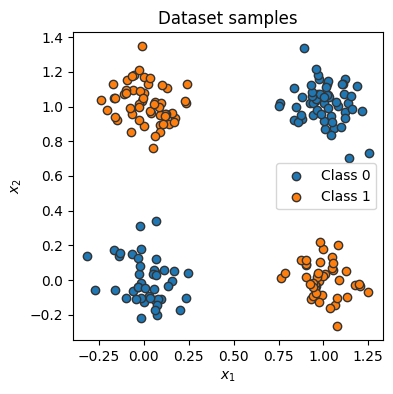

In [19]:
visualize_samples(dataset.data, dataset.label)
plt.show()

### The data loader class